# 11 · Nitrogen rates and N fixation

Compare maize nitrogen responses under two water regimes and peanut yield with biological N fixation on and off.

## You will learn

- Replace a fertilizer schedule with rates from 0 to 200 kg N/ha.
- Compare rainfed and irrigated maize yield response curves.
- Switch peanut symbiosis on and off while keeping nitrogen simulation on.

In [1]:
LESSON = "11_nitrogen"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load the tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the copied Gainesville maize (1982) and Florunner peanut (1979) inputs in `runs/`.

In [4]:
# Select both stock cases and list their copied inputs.
maize_inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
peanut_inputs = {
    "filex": RUNS / "UFGA7901.PNX",
    "weather": RUNS / "UFGA7901.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
for crop, inputs in (("Maize", maize_inputs), ("Peanut", peanut_inputs)):
    print(crop + ":", ", ".join(inputs[key].relative_to(HERE).as_posix()
                               for key in ("filex", "weather", "soil")))

Maize: runs/UFGA8201.MZX, runs/UFGA8201.WTH, runs/SOIL.SOL
Peanut: runs/UFGA7901.PNX, runs/UFGA7901.WTH, runs/SOIL.SOL


Keep water and nitrogen simulation on, remove fertilizer, and check maize treatments 1 and 3.

In [5]:
# Check the rainfall-only and stock-irrigated maize baselines.
maize_experiment = {"treatments": {
    1: {"controls": {"water": "Y", "nitrogen": "Y"}, "irrigation": [], "fertilizer": []},
    3: {"controls": {"water": "Y", "nitrogen": "Y"}, "fertilizer": []},
}}
water_regimes = {1: "Rainfed", 3: "Irrigated"}
for treatment in (1, 3):
    sim = dl.Simulation(**maize_inputs, treatment=treatment, management=maize_experiment)
    problems = sim.check(verbose=False)
    print(water_regimes[treatment] + " problems:", problems)

Rainfed problems: []
Irrigated problems: []


🌱 Crop idea  
`water: "Y"` and `nitrogen: "Y"` let water and nitrogen availability affect growth.
`irrigation: []` removes treatment 1's stock 13 mm irrigation; treatment 3 keeps its dated irrigation schedule.

Replace the stock fertilizer schedule with five N rates, split equally between 7 April and 17 May.

In [6]:
# Build complete fertilizer schedules and display their totals.
n_rates = [0, 50, 100, 150, 200]
fertilizer_event = {"material": "FE001", "application": "AP001", "depth": 10}
fertilizer_dates = ["1982-04-07", "1982-05-17"]
fertilizer_levels = {
    rate: [dict(fertilizer_event, date=day, n=rate / 2) for day in fertilizer_dates]
    if rate else [] for rate in n_rates
}
dl.to_dataframe([{
    "N rate (kg N/ha)": rate,
    "Applications": len(events),
    "N per application (kg N/ha)": rate / 2,
    "Total applied N (kg N/ha)": sum(event["n"] for event in events),
} for rate, events in fertilizer_levels.items()])

,N rate (kg N/ha),Applications,N per application (kg N/ha),Total applied N (kg N/ha)
0,0,0,0.0,0.0
1,50,2,25.0,50.0
2,100,2,50.0,100.0
3,150,2,75.0,150.0
4,200,2,100.0,200.0


🐍 Python idea  
A fertilizer factor replaces the whole schedule; `[]` means no fertilizer, while omitting the section keeps the stock schedule.
`FE001` is ammonium nitrate, `AP001` is broadcast without incorporation, and `depth` is in cm; `n` is elemental N in kg/ha.

Run the five fertilizer rates for both water regimes and display the ten labelled scenarios.

In [7]:
# Run the maize sweep and show applied N, irrigation and grain yield.
maize_rows = dl.run_sweep(**maize_inputs, treatments=[1, 3], management=maize_experiment,
                          factors={"fertilizer": fertilizer_levels})
maize_results = dl.to_dataframe(maize_rows)
maize_comparison = maize_results.loc[maize_results["scenario"] != "base"].copy()
maize_comparison["Water regime"] = maize_comparison["TRNO"].map(water_regimes)
maize_comparison[["Water regime", "fertilizer", "NICM", "IRCM", "HWAM"]].rename(
    columns={"fertilizer": "N rate (kg N/ha)", "NICM": "Applied N (kg N/ha)",
             "IRCM": "Irrigation (mm)", "HWAM": "Grain yield (kg/ha)"})

,Water regime,N rate (kg N/ha),Applied N (kg N/ha),Irrigation (mm),Grain yield (kg/ha)
2,Rainfed,0.0,0,0,602
3,Irrigated,0.0,0,264,620
4,Rainfed,50.0,50,0,2073
5,Irrigated,50.0,50,264,4419
6,Rainfed,100.0,100,0,1832
7,Irrigated,100.0,100,264,7019
8,Rainfed,150.0,150,0,1872
9,Irrigated,150.0,150,264,8951
10,Rainfed,200.0,200,0,2091
11,Irrigated,200.0,200,264,9896


🐍 Python idea  
`run_sweep()` also returns one `base` row per treatment; those zero-fertilizer baselines repeat the 0-N scenarios here.
Filtering `scenario != "base"` keeps five rates per water regime, and `NICM` checks the N actually applied.

Plot one maize yield response curve per water regime to compare the same N rates.

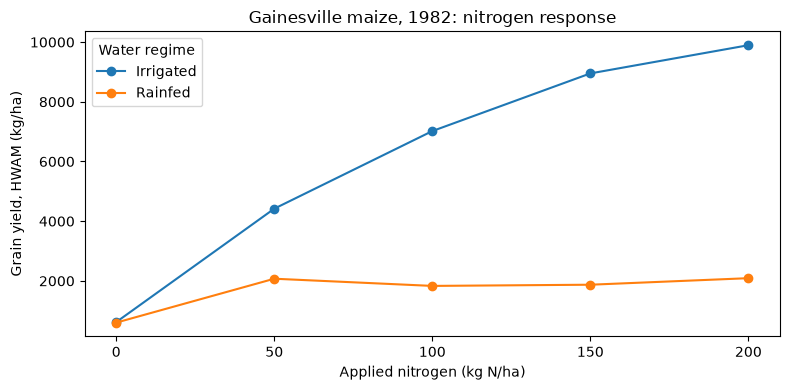

In [8]:
# Plot rainfed and irrigated maize grain yield against applied N.
yield_curves = maize_comparison.pivot(index="fertilizer", columns="Water regime", values="HWAM")
ax = yield_curves.plot(marker="o", figsize=(8, 4))
ax.set(xlabel="Applied nitrogen (kg N/ha)", ylabel="Grain yield, HWAM (kg/ha)",
       title="Gainesville maize, 1982: nitrogen response")
ax.set_xticks(n_rates)
plt.tight_layout()
plt.show()

🌱 Crop idea  
Irrigated yield rises from 620 to 9,896 kg/ha as N rises from 0 to 200 kg N/ha; rainfed yield rises from 602 to 2,091 kg/ha.
The rainfed curve is uneven (2,073 at 50 N, then 1,832 at 100 N); the smaller response is consistent with water limitation, but yield alone does not explain the dip.

Run Florunner peanut treatment 1 with symbiosis on and off, keeping water and nitrogen simulation on.

In [9]:
# Compare peanut N fixation controls with no fertilizer added.
peanut_rows = []
peanut_runs = {}
for label, symbiosis in (("Fixation on", "Y"), ("Fixation off", "N")):
    peanut_experiment = {"treatments": {1: {
        "controls": {"water": "Y", "nitrogen": "Y", "symbiosis": symbiosis},
        "fertilizer": [],
    }}}
    peanut_sim = dl.Simulation(**peanut_inputs, treatment=1, management=peanut_experiment)
    peanut_result = peanut_sim.run()
    peanut_runs[label] = peanut_result.run_dir
    row = dl.read_summary(peanut_result.run_dir)[0]
    final_n = dl.read_plant_nitrogen(peanut_result.run_dir)[-1]
    peanut_rows.append(dict(row, Fixation=label, NFXC=final_n["NFXC"]))
dl.to_dataframe(peanut_rows)[["Fixation", "NICM", "IRCM", "HWAM", "CNAM", "NFXC"]].rename(
    columns={"NICM": "Applied N (kg N/ha)", "IRCM": "Irrigation (mm)",
             "HWAM": "Harvest yield (kg/ha)", "CNAM": "Tops N at maturity (kg N/ha)",
             "NFXC": "Final fixed N (kg N/ha)"})

,Fixation,Applied N (kg N/ha),Irrigation (mm),Harvest yield (kg/ha),Tops N at maturity (kg N/ha),Final fixed N (kg N/ha)
0,Fixation on,0,0,4423,326,307.3
1,Fixation off,0,0,462,26,0.0


🌱 Crop idea  
`symbiosis: "N"` disables biological N fixation; `nitrogen: "N"` would remove N limitation and answer a different question.
The stock peanut treatment is labelled IRRIGATED but points to irrigation level 0, so both runs use rainfall only.

Plot cumulative fixed N to check what the peanut symbiosis switch changes during the season.

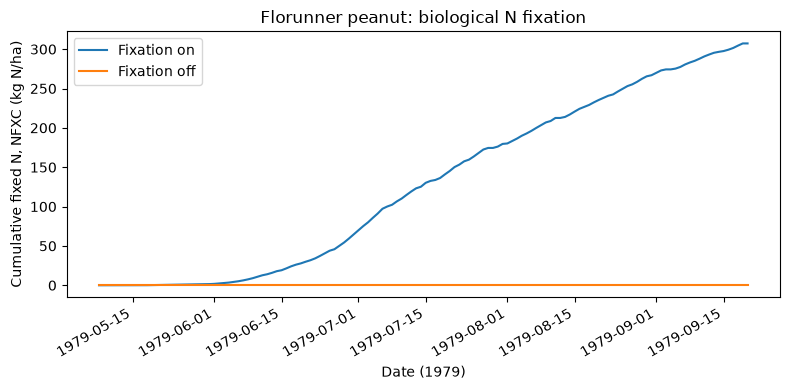

In [10]:
# Plot cumulative biological N fixation for the two peanut runs.
fig, ax = plt.subplots(figsize=(8, 4))
for label, run_dir in peanut_runs.items():
    plant_n = dl.to_dataframe(dl.read_plant_nitrogen(run_dir))
    ax.plot(plant_n["DATE"], plant_n["NFXC"], label=label)
ax.set(xlabel="Date (1979)", ylabel="Cumulative fixed N, NFXC (kg N/ha)",
       title="Florunner peanut: biological N fixation")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

🌱 Crop idea  
Fixation on gives 307.3 kg N/ha fixed and 4,423 kg/ha harvest yield; fixation off gives 0 fixed N and 462 kg/ha yield.
Tops N at maturity falls from 326 to 26 kg N/ha, consistent with fixation supplying much of the peanut crop's N in this simulation.

## Your turn

Compare a new maize N rate with zero N under both water regimes.

Hint: edit `chosen_n = 75` (kg N/ha), then run this cell.

In [11]:
# Rebuild the maize comparison for a chosen N rate and zero N.
chosen_n = 75
exercise_inputs = {
    "filex": RUNS / "UFGA8201.MZX", "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL", "executable": dssat,
}
exercise_rows = []
for treatment, regime in ((1, "Rainfed"), (3, "Irrigated")):
    for rate in (0, chosen_n):
        events = [{"date": day, "material": "FE001", "application": "AP001",
                   "depth": 10, "n": rate / 2}
                  for day in ("1982-04-07", "1982-05-17")] if rate else []
        treatment_data = {"controls": {"water": "Y", "nitrogen": "Y"}, "fertilizer": events}
        if treatment == 1:
            treatment_data["irrigation"] = []
        exercise_sim = dl.Simulation(**exercise_inputs, treatment=treatment,
                                     management={"treatments": {treatment: treatment_data}})
        exercise_result = exercise_sim.run()
        row = dl.read_summary(exercise_result.run_dir)[0]
        if rate == 0:
            zero_yield = row["HWAM"]
        exercise_rows.append({"Water regime": regime, "Requested N (kg N/ha)": rate,
                              "Reported applied N (kg N/ha)": row["NICM"], "Grain yield (kg/ha)": row["HWAM"],
                              "Yield gain over zero N (kg/ha)": row["HWAM"] - zero_yield})
dl.to_dataframe(exercise_rows)

,Water regime,Requested N (kg N/ha),Reported applied N (kg N/ha),Grain yield (kg/ha),Yield gain over zero N (kg/ha)
0,Rainfed,0,0,602,0
1,Rainfed,75,76,2119,1517
2,Irrigated,0,0,620,0
3,Irrigated,75,76,5823,5203


🌱 Crop idea  
DSSAT rounds each requested 37.5 kg N/ha application to 38 while preparing its internal inputs, so these simulations apply 76 kg N/ha.

## Recap

- A fertilizer factor replaces the stock schedule, with N amounts in kg N/ha.
- Keep water and nitrogen simulation on to compare N responses under actual water regimes.
- The peanut symbiosis switch tests biological N fixation while soil N remains available.

Next: [Phosphorus (forthcoming)](../README.md).